# From a plate reader to a number you can compare

A plate reader produces a few hundred OD traces per run. It is the single most
common measurement in the field, and turning it into a growth rate is where most
of the errors live — not in the fitting, which converges on almost anything, but
in deciding *which* number the fit produced and whether it means what the next
step needs it to mean.

This notebook fits a **real 96-well run** (Growthcurver's published dataset: 145
timepoints over 24 hours) and then does the thing that makes the number useful:
sets it beside what a genome-scale model predicts.

Three claims it will not let you make:

* that a converged fit is a good fit,
* that "µmax" means one thing, or
* that a measurement above a stoichiometric upper bound is a discovery.

In [1]:
import omicverse as ov
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — The data

Measured, not simulated. A fitter shown only on curves generated by its own
equations has not been shown to work on anything.

In [2]:
od = ov.synbio.fetch_growth_dataset()
print(od.shape, '| time', od['time_h'].min(), '-', od['time_h'].max(), 'h')
print(od.iloc[:3, :5].round(4).to_string())

(145, 97)

 | time 0.0 - 24.0 h
   time_h      A1      B1      C1      D1
0  0.0000  0.0535  0.0450  0.0525  0.0560
1  0.1667  0.0480  0.0439  0.0514  0.0535
2  0.3333  0.0559  0.0500  0.0471  0.0490


**There are no blank wells in this set.** 95 of the 96 wells grow six- to
thirteen-fold, column 12 included. Nominating a column as the blank and
subtracting it removes real signal — doing that drops the median R² from 0.998 to
0.39. The honest baseline here is the t=0 reading.

If your own reader exports a CSV, `read_plate_reader` parses either the wide
layout (one column per well) or the long one (well / time / value) into the same
shape this notebook uses.

In [3]:
od.to_csv('plate_run_wide.csv', index=False)
reparsed = ov.synbio.read_plate_reader('plate_run_wide.csv', time_col='time_h')
print('round trip:', reparsed.shape, '| identical:',
      bool((reparsed.iloc[:, 1:].round(6) == od.iloc[:, 1:].round(6)).all().all()))

round trip: (145, 97) | identical: True


In [4]:
baseline = float(od.iloc[0, 1:].mean())
growth = od.iloc[:, 1:].max() / od.iloc[:, 1:].iloc[0]
print(f'baseline OD {baseline:.4f}')
print(f'fold change across wells: min {growth.min():.1f}x, median {growth.median():.1f}x')

baseline OD 0.0506
fold change across wells: min 2.8x, median 8.8x


## 2 — One well, four models

The models are not interchangeable and the difference is not cosmetic.
`GROWTH_MODELS` names all five: `logistic` is symmetric with no explicit lag
term; `gompertz` is asymmetric and parameterises lag directly, which is why it
dominates the microbiology literature; `richards` adds a shape parameter for when
neither fits; `baranyi` is the mechanistic reference in predictive microbiology;
and `exponential` covers the early phase alone.

In [5]:
print('available models:', ov.synbio.GROWTH_MODELS)
fits = ov.synbio.fit_growth_curves(od, blank=baseline)
best_well = fits['mu_max'].idxmax()
comparison = ov.synbio.compare_growth_models(od['time_h'], od[best_well], blank=baseline)
print(comparison.round(4).to_string())

available models: ('gompertz', 'logistic', 'richards', 'baranyi', 'exponential')


          mu_max  slope_max     lag  r_squared    rmse        aic  converged note  preferred
model                                                                                       
logistic  0.7955     0.1833  5.5016     0.9998  0.0030 -1676.9269       True            True
richards  0.7956     0.1834  5.5018     0.9998  0.0030 -1674.9284       True           False
baranyi   0.7955     0.1833  0.0000     0.9998  0.0030 -1674.9269       True           False
gompertz  1.1251     0.1891  5.4494     0.9988  0.0067 -1443.6516       True           False


Read the `aic` column before the `mu_max` column.

In [6]:
print('AIC prefers:', comparison.attrs['preferred_model'])
print('µmax spread across usable models: %.2fx' % comparison.attrs['mu_max_spread'])
print(comparison.attrs['note'])

AIC prefers: logistic
µmax spread across usable models: 1.41x
AIC 最优:'logistic'。可用模型之间 µmax 相差 1.41 倍 —— 各模型把拐点放在不同高度(Gompertz 在 A/e,logistic 在 A/2),所以它们对'比速率'的定义本就不同。要把 µmax 和 FBA 比,先在这里选模型,再传给 fit_growth_curves(model=...)。


All four fit the trace essentially perfectly (R² ≈ 1.000), and they disagree
about µmax by **1.4×**. That is not noise and it is not a bug: each model places
the inflection at a different height — A/e for Gompertz, A/2 for logistic — and
the specific rate is evaluated there. They are answering slightly different
questions and the answers differ accordingly.

The default is Gompertz. On this well it is the model AIC likes **least**, by
233 units. Which is why the table exists.

## 3 — What the fit actually reports

In [7]:
fit = ov.synbio.fit_growth_curve(od['time_h'], od[best_well], blank=baseline)
print(fit)
print(f'  µmax      {fit.mu_max:.4f} /h   — specific rate, (dOD/dt)/OD at the inflection')
print(f'  slope_max {fit.slope_max:.4f} OD/h — the sigmoid\'s own steepest slope')

GrowthFit(gompertz, µmax=1.1251 /h, td=0.62 h, lag=5.45 h, A=0.464, R²=0.9988)
  µmax      1.1251 /h   — specific rate, (dOD/dt)/OD at the inflection
  slope_max 0.1891 OD/h — the sigmoid's own steepest slope


Two rates, two units, and only one of them can be compared with a model's growth
rate or turned into a doubling time. `slope_max` is what the curve does on the
page; `mu_max` is what the culture does per unit of itself.

The figure draws the tangent with `slope_max`, because a tangent on an OD-vs-time
axis has units of OD/h. Drawing it with `mu_max` produces a line 5.95× too steep
that is not tangent to anything — and then the eye cannot be used to check the
fit, which was the only reason to draw it.

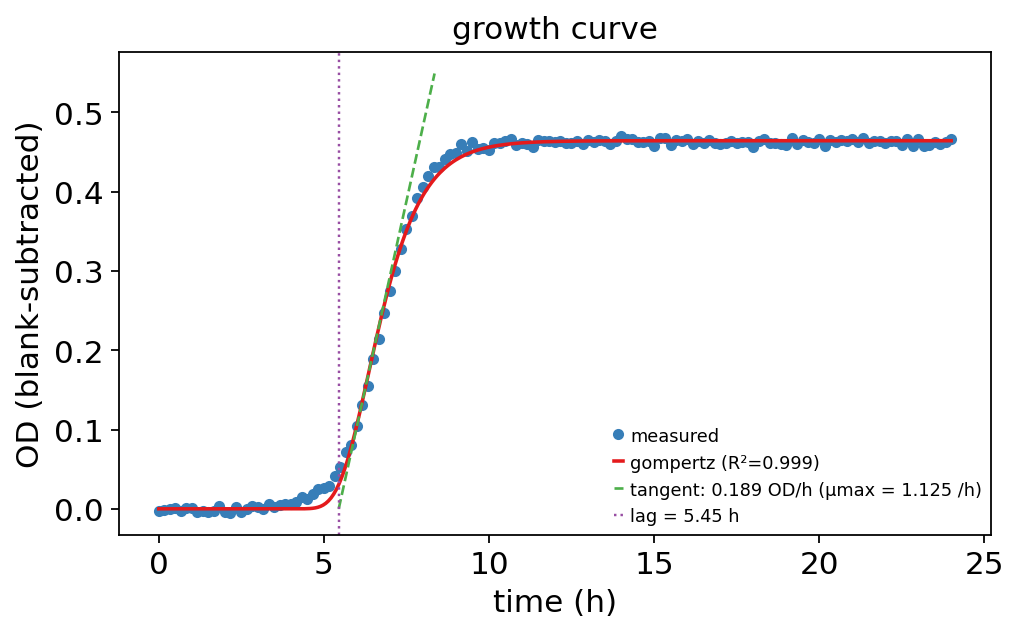

In [8]:
ov.synbio.plot_growth_curves(od['time_h'], od[best_well], fit=fit, blank=baseline)
None

## 4 — A whole plate

`fit_growth_curves` returns one tidy row per well. `good_fit` is the column to
filter on, and `mu_max` is `NaN` — not a number — wherever the fit is not usable.

In [9]:
print(f'{len(fits)} wells | {int(fits["good_fit"].sum())} good fits | '
      f'median R² {fits["r_squared"].median():.4f}')
print(fits[['mu_max', 'lag_h', 'carrying_capacity', 'r_squared']].describe().loc[
    ['min', '50%', 'max']].round(3).to_string())

96 wells | 96 good fits | median R² 0.9985


     mu_max   lag_h  carrying_capacity  r_squared
min   0.394   5.449              0.100      0.994
50%   0.788   7.206              0.390      0.999
max   1.125  13.082              0.592      0.999

### Why `NaN` and not a number

A four-parameter sigmoid fits any monotone trace, so R² is not quality control.
And µ = slope/OD is unbounded as OD → 0. Put those together and a well that never
grew comes back with an excellent-looking rate.

In [10]:
import numpy as np
flat = np.full(len(od), 0.05) + np.random.default_rng(0).normal(0, 0.002, len(od))
dud = ov.synbio.fit_growth_curve(od['time_h'], flat)
print('µmax on a flat trace:', dud.mu_max)
print(dud.notes[-1])

µmax on a flat trace: nan
OD 只变化了 0.0087(≈1.19 倍),低于 min_amplitude=0.05 / min_fold_change=1.5 —— 这个孔没有长起来。µmax 返回 nan 而不是拟合值:比速率是 slope/OD,OD 趋近 0 时它会爆掉(平坦曲线能给出 28 /h,即 1.5 分钟倍增)。


Before the amplitude gate this returned **28 /h — a 1.5-minute doubling time** —
with `good_fit=False` but still a number in the `mu_max` column, where
`nlargest()` finds it and puts it at the top of the table. `NaN` propagates;
a plausible-looking number does not.

## 5 — The join that makes the number mean something

A growth rate on its own is a growth rate. Set beside a genome-scale model it
becomes a statement about whether the model and the culture agree.

In [11]:
model = ov.synbio.load_gem('textbook')
top3 = fits.nlargest(3, 'mu_max')['mu_max'].to_dict()
gompertz_table = ov.synbio.compare_growth_to_model(top3, model, growth_model='gompertz')
print(gompertz_table[['measured', 'fba', 'rba', 'measured_over_fba']].round(3).to_string())

INFO:cobra.io.web.load:Attempting to fetch 'textbook' from the Cobrapy repository.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


       measured    fba    rba  measured_over_fba
label                                           
A7        1.125  0.874  0.874              1.287
G5        1.074  0.874  0.874              1.228
H5        1.066  0.874  0.874              1.220


In [12]:
print(gompertz_table.attrs['warning'])

3 个样品的实测 µmax 超过 FBA 上界 5% 以上 —— FBA 是化学计量上界,实测不该超过它。按先后顺序查:(1) 生长模型的选择 —— 这些 µmax 来自 'gompertz',换成 AIC 更优的模型可能整体降低约 1.4 倍,先跑 compare_growth_models;(2) 培养基约束是否比实际更严(模型的碳源上限);(3) 时间单位是否都是小时。注意:OD 到干重的换算不会改变这个比值 —— µmax 是比速率,OD 与干重之间的任何常数因子都会约掉。


**FBA is a stoichiometric upper bound.** A measured rate above it is not a
discovery; it means the comparison is not yet set up correctly, and the function
says so rather than printing the ratio and moving on.

Follow its first suggestion — the growth model — and refit with the one AIC
preferred in §2.

In [13]:
preferred = comparison.attrs['preferred_model']
refits = ov.synbio.fit_growth_curves(od, blank=baseline, model=preferred)
table = ov.synbio.compare_growth_to_model(refits.nlargest(3, 'mu_max')['mu_max'].to_dict(),
                                          model, growth_model=preferred)
print(table[['measured', 'fba', 'measured_over_fba']].round(3).to_string())
print('warning:', table.attrs.get('warning', 'none — the measurement is below the bound'))

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


       measured    fba  measured_over_fba
label                                    
A7        0.795  0.874              0.910
G5        0.758  0.874              0.867
H5        0.757  0.874              0.866


**1.29 becomes 0.91 and the warning goes away**, on the same plate and the same
model, by choosing the growth model the data prefer.

This is worth sitting with. The "measurement exceeds the thermodynamic bound"
anomaly was entirely an artefact of a default, and the evidence against that
default was in a table printed two sections earlier. Nothing about the culture
changed.

One thing that does *not* explain the ratio, despite being the obvious suspect:
the OD-to-dry-weight conversion. µmax is a **specific** rate, so if
`X_gDW = k · OD` then `(1/X)(dX/dt) = (1/OD)(dOD/dt)` and any constant `k`
cancels exactly. There is no `od_to_gdw=` argument because it would do nothing.

## 6 — Dose-response

The other measurement a plate reader makes. `fetch_dose_response_dataset` pulls a
real one: Streibig's ryegrass assay — root length against ferulic acid
concentration, seven levels with three to six replicates each, published with the
R package *drc*.

Real replicates matter here. A dose-response demonstrated on a smooth curve drawn
from the equation being fitted demonstrates nothing; the interesting question is
what the fit does when the replicates at one dose span a factor of two, which
these do.

In [14]:
doses = ov.synbio.fetch_dose_response_dataset()
print(doses.attrs['units'])
print(doses.groupby('concentration')['response'].agg(['size', 'mean', 'std']).round(3).to_string())

{'concentration': 'µM ferulic acid', 'response': 'root length (cm)'}
               size   mean    std
concentration                    
0.00              6  7.749  0.415
0.94              3  7.673  0.724
1.88              3  6.415  0.476
3.75              3  3.015  1.160
7.50              3  1.034  0.166
15.00             3  0.679  0.150
30.00             3  0.303  0.119


In [15]:
response = ov.synbio.dose_response(doses['concentration'], doses['response'])
print(response)
print(f'IC50 {response.ec50:.3f} µM | Hill {response.hill_slope:.2f} | '
      f'top {response.top:.2f} -> bottom {response.bottom:.2f} cm')

DoseResponse(IC50=2.992, hill=-2.81, R²=0.9709, MIC=1.369)
IC50 2.992 µM | Hill -2.81 | top 7.98 -> bottom 0.46 cm


**IC50 = 2.99 µM against the ≈ 3.06 µM that *drc* reports for the same data.**
That agreement is the reason to use a published dataset: it checks the
implementation against something outside itself, which a self-generated curve
cannot do.

The Hill slope is negative because the response *decreases* with dose —
`inhibitory` records that, and the MIC is derived accordingly.

In [16]:
print('inhibitory:', response.inhibitory, '| MIC:', round(response.mic, 3))
print('R²:', round(response.r_squared, 4))
for note in response.notes:
    print(' -', note)

inhibitory: True | MIC: 1.369
R²: 0.9709
 - 6 个零浓度点用于确定上平台,不参与对数轴拟合(Hill 方程在 c=0 处无定义)。


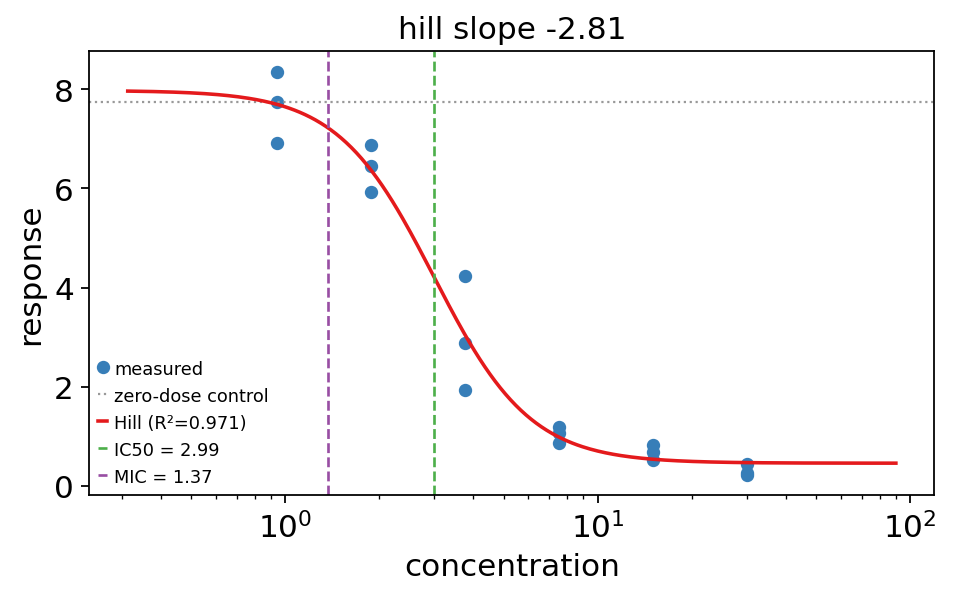

In [17]:
ov.synbio.plot_dose_response(doses['concentration'], doses['response'], response)
None

Note the scatter at 3.75 µM — three replicates spanning 1.9 to 4.1 cm, right at
the steepest part of the curve. That single dose carries most of the information
about the IC50 and most of the uncertainty in it, which is an argument for
choosing dose spacing around the expected transition rather than evenly in log
space.

## What to carry away

**The fit is not the measurement.** Four models fit the same real trace at
R² ≈ 1.000 and disagree about the growth rate by 1.4×. Choose with AIC, record
which one you chose — `compare_growth_to_model` carries it in `.attrs` and names
it in the warning — and do not compare a µmax fitted one way with a µmax fitted
another.

**Converged is not good, and good is not usable.** R² cannot reject a well that
never grew, because a four-parameter sigmoid fits any monotone trace. The
amplitude gate can, and it returns `NaN` so the rejection propagates instead of
being silently overridden by the next `nlargest()`.

**A ratio above 1 against an upper bound is a bug report.** Here it was a default
growth model, and the evidence was already on the page.